# IR Protocol

In [ ]:
import json
import matplotlib.pyplot as plt

## Load Data

In [2]:
raw_pronto_codes_file = "./pronto-code/raw-pronto-codes.json"

In [3]:
raw_pronto_codes = json.loads(open(raw_pronto_codes_file, "r").read())
raw_pronto_codes[:5]

[{'hex': '0000 006D 0051 0000 0028 0016 0028 0015 0029 0063 0028 0063 0028 0016 0029 0015 0029 0062 0029 0062 0028 0016 0029 0015 0028 0063 0028 0016 0028 0063 0029 0015 0029 0015 0029 0015 0029 0062 0029 0015 0028 0016 0029 0015 0029 0062 0028 0016 0028 0016 0028 0016 0028 0016 0028 0016 0029 0015 0029 0062 0029 0062 0029 0015 0029 0015 0029 0062 0028 0016 0028 0016 0028 0063 0029 0062 0029 0062 0028 0016 0029 0062 0029 0062 0029 0015 0029 0015 002D 005D 0029 0062 0029 0062 0029 0015 0029 0062 0029 0062 0029 0015 0029 0013 002B 0062 0029 0062 002A 0060 0029 0015 0029 0062 0028 0063 0029 0015 0029 0016 0028 0015 0029 0062 0028 0016 0028 0016 0028 0016 0028 0062 0029 0015 0029 0015 0029 0016 0028 0015 0029 0015 0029 0015 0029 0016 0027 0017 0028 0016 0028 0063 0028 0016 0027 0016 0029 0016 0027 0018 0028 0015 0028 0062 0028 0180\r\n',
  'label': '24-to-25-cool-fan-high'},
 {'hex': '0000 006D 0051 0000 0029 0015 0029 0015 0029 0061 0029 0061 002A 0015 0029 0015 0029 0062 0029 0062 0028 0

## Processing

In [4]:
def parse_pronto_code(pronto_code):
    """Parse a Pronto code string into a list of decimal integers"""
    return [int(x, 16) for x in pronto_code.split()]

In [ ]:
pronto_codes = []
for code in raw_pronto_codes:
    pronto_code = code
    pronto_code["dec"] = parse_pronto_code(code["hex"])
    pronto_codes.append(pronto_code)
pronto_codes[:5]

[{'hex': '0000 006D 0051 0000 0028 0016 0028 0015 0029 0063 0028 0063 0028 0016 0029 0015 0029 0062 0029 0062 0028 0016 0029 0015 0028 0063 0028 0016 0028 0063 0029 0015 0029 0015 0029 0015 0029 0062 0029 0015 0028 0016 0029 0015 0029 0062 0028 0016 0028 0016 0028 0016 0028 0016 0028 0016 0029 0015 0029 0062 0029 0062 0029 0015 0029 0015 0029 0062 0028 0016 0028 0016 0028 0063 0029 0062 0029 0062 0028 0016 0029 0062 0029 0062 0029 0015 0029 0015 002D 005D 0029 0062 0029 0062 0029 0015 0029 0062 0029 0062 0029 0015 0029 0013 002B 0062 0029 0062 002A 0060 0029 0015 0029 0062 0028 0063 0029 0015 0029 0016 0028 0015 0029 0062 0028 0016 0028 0016 0028 0016 0028 0062 0029 0015 0029 0015 0029 0016 0028 0015 0029 0015 0029 0015 0029 0016 0027 0017 0028 0016 0028 0063 0028 0016 0027 0016 0029 0016 0027 0018 0028 0015 0028 0062 0028 0180\r\n',
  'label': '24-to-25-cool-fan-high',
  'dec': [0,
   109,
   81,
   0,
   40,
   22,
   40,
   21,
   41,
   99,
   40,
   99,
   40,
   22,
   41,
   21,

## Clusters

In [6]:
from collections import Counter

all_hex_codes = []
all_dec_codes = []
for code in pronto_codes:
    all_hex_codes.extend(code["hex"].split())
    all_dec_codes.extend(code["dec"])

In [7]:
hex_counts = Counter(all_hex_codes)
hex_counts

Counter({'0029': 170,
         '0028': 166,
         '002A': 159,
         '0016': 106,
         '0015': 94,
         '0014': 84,
         '0027': 82,
         '0062': 81,
         '0063': 56,
         '0017': 55,
         '0060': 50,
         '002B': 42,
         '0013': 38,
         '0064': 25,
         '0026': 20,
         '0000': 16,
         '0018': 16,
         '005F': 12,
         '0061': 10,
         '006D': 8,
         '0051': 8,
         '0180': 8,
         '0025': 5,
         '0012': 4,
         '0065': 3,
         '0019': 3,
         '002D': 2,
         '005D': 1,
         '0066': 1,
         '0024': 1,
         '002C': 1,
         '005E': 1})

In [8]:
dec_counts = Counter(all_dec_codes)
dec_counts

Counter({41: 170,
         40: 166,
         42: 159,
         22: 106,
         21: 94,
         20: 84,
         39: 82,
         98: 81,
         99: 56,
         23: 55,
         96: 50,
         43: 42,
         19: 38,
         100: 25,
         38: 20,
         0: 16,
         24: 16,
         95: 12,
         97: 10,
         109: 8,
         81: 8,
         384: 8,
         37: 5,
         18: 4,
         101: 3,
         25: 3,
         45: 2,
         93: 1,
         102: 1,
         36: 1,
         44: 1,
         94: 1})

(array([ 16.,   0., 381.,  19.,  26., 622.,   0.,   0.,   0.,   0.,   8.,
          0., 211.,  29.,   8.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   8.]),
 array([  0.  ,   7.68,  15.36,  23.04,  30.72,  38.4 ,  46.08,  53.76,
         61.44,  69.12,  76.8 ,  84.48,  92.16,  99.84, 107.52, 115.2 ,
        122.88, 130.56, 138.24, 145.92, 153.6 , 161.28, 168.96, 176.64,
        184.32, 192.  , 199.68, 207.36, 215.04, 222.72, 230.4 , 238.08,
        245.76, 253.44, 261.12, 268.8 , 276.48, 284.16, 291.84, 299.52,
        307.2 , 314.88, 322.56, 330.24, 337.92, 345.6 , 353.28, 360.96,
        368.64, 376.32, 384.  ]),
 <BarContainer object of 50 artists>)

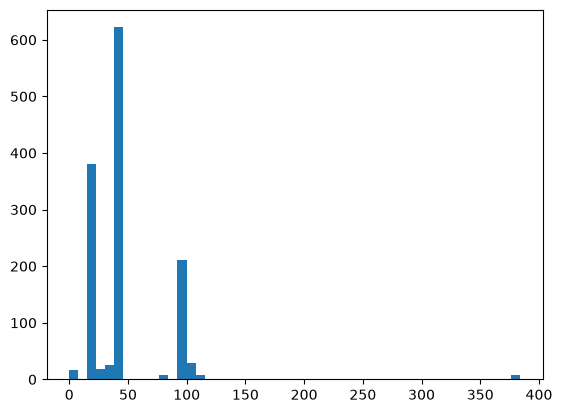

In [9]:
plt.hist(all_dec_codes, bins=50)

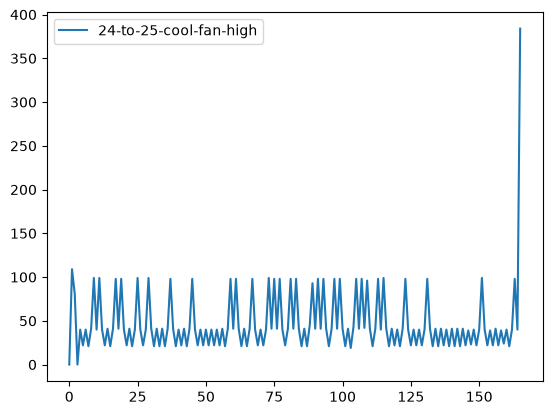

In [10]:
idx = 0
plt.plot(pronto_codes[idx]["dec"], label=pronto_codes[idx]["label"])
plt.legend()

In [ ]:
def regroup(data: Counter[int], width = 10):
    regroups = {}
    for key, value in data.items():
        for existing_key in regroups.keys():
            if existing_key - width < key <= existing_key + width:
                regroups[existing_key].append((key, value))
                break
        else:
            regroups[key] = [(key, value)]
    reregroups = {}
    for key, value in regroups.items():
        mode_key = key
        for k, v in value:
            if v > regroups[key][0][1]:
                mode_key = k
        reregroups[mode_key] = value
    return reregroups

In [58]:
regrouped_dec_counts = regroup(dec_counts, width=10)
regrouped_dec_counts

{0: [(0, 16)],
 100: [(109, 8), (100, 25), (101, 3), (102, 1)],
 81: [(81, 8)],
 41: [(40, 166),
  (41, 170),
  (45, 2),
  (43, 42),
  (42, 159),
  (39, 82),
  (38, 20),
  (37, 5),
  (36, 1),
  (44, 1)],
 22: [(22, 106),
  (21, 94),
  (19, 38),
  (23, 55),
  (24, 16),
  (20, 84),
  (25, 3),
  (18, 4)],
 98: [(99, 56), (98, 81), (93, 1), (96, 50), (97, 10), (95, 12), (94, 1)],
 384: [(384, 8)]}

In [59]:
len(regrouped_dec_counts)

7

Text(0, 0.5, 'Decimal Code')

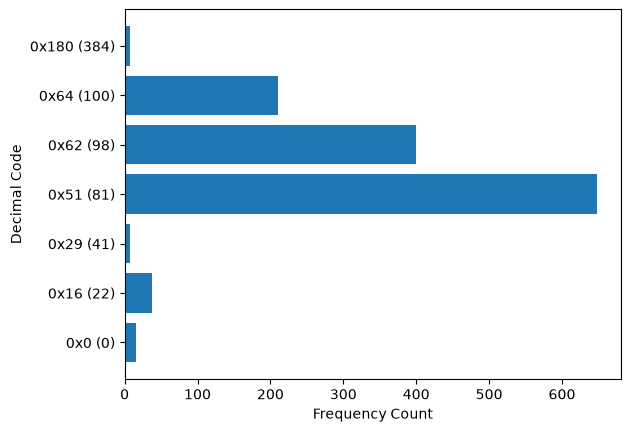

In [ ]:
x = [x for x in regrouped_dec_counts.keys()]
y = [sum([v for _, v in regrouped_dec_counts[x]]) for x in x]
x = [f"{hex(x)} ({x})" for x in sorted(x)]
plt.barh(x, y)
plt.xlabel("Frequency Count")
plt.ylabel("Pronto Code")